<a href="https://colab.research.google.com/github/tettty1981-lang/data-analytics-course/blob/main/HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [3]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01


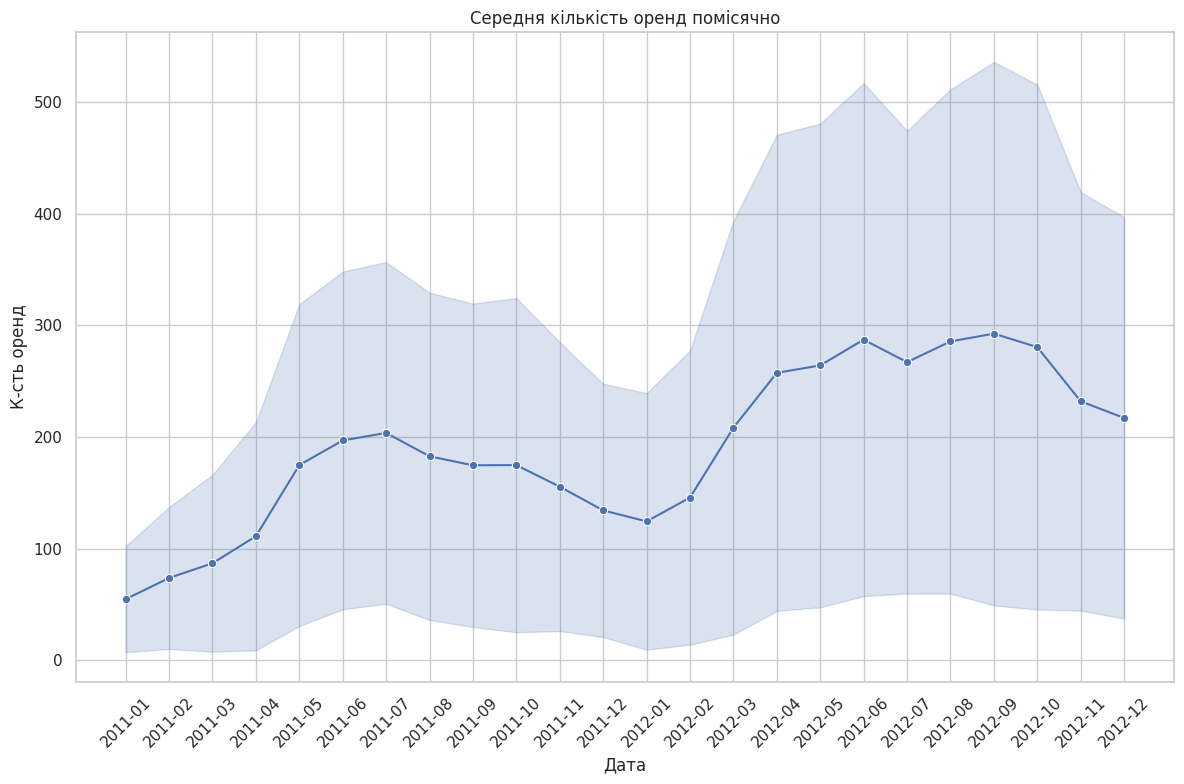

In [5]:
plt.figure(figsize=(12, 8))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Cередня кількість оренд помісячно')
plt.xlabel('Дата')
plt.ylabel('К-сть оренд')
plt.xticks(rotation=45)
plt.tight_layout();


Найбільша невизначеність (розкид погодинних оренд) спостерігається у вересні–жовтні 2012 року, а також у квітні–серпні 2012 — тобто в другій половині періоду даних довірчий інтервал помітно ширший, ніж у 2011 році. Це означає, що попит на оренди в 2012 став не лише вищим у середньому, а й нестабільнішим — годинні значення сильніше розкидані навколо середнього, ймовірно через ріст сервісу і ширший діапазон користувачів/погодних умов.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**

1.Яка візуальна різниця між Pandas та Seaborn гістограмами?

Seaborn підписує вісь X автоматично (temp), Pandas — ні.

Назви осі Y різні: Count у Seaborn, Frequency у Pandas.

Колір: у Seaborn стриманіший, приглушений синій, у Pandas — насиченіший.

2.Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

Це щось схоже на лінію тренду. Мені вона схожа на зглажену версію гістограми. Вона показує де значення температури зустрічаються частіше (крива вища), а де рідше (крива нижча).

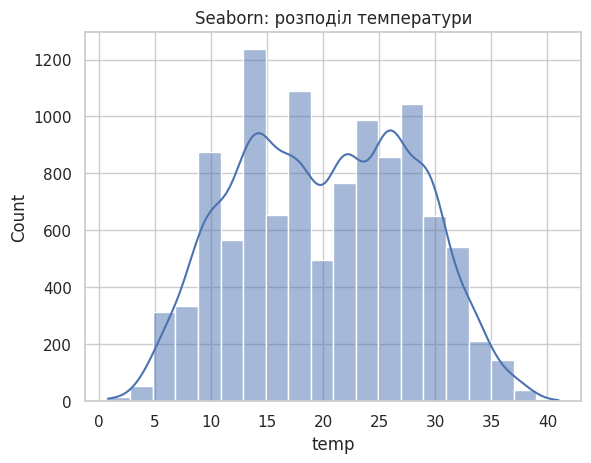

In [6]:
# Seaborn
sns.histplot(data=df, x='temp', bins=20, kde=True)
plt.title('Seaborn: розподіл температури')
plt.show()

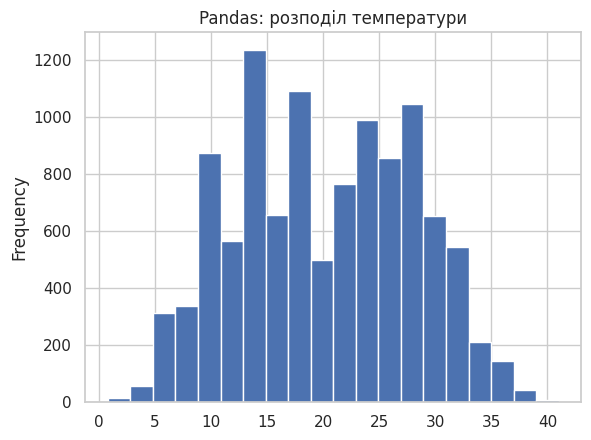

In [7]:
# Pandas
df['temp'].plot(kind='hist', bins=20)
plt.title('Pandas: розподіл температури')
plt.show()

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

Seaborn зафарбовує коробки кольором, тоді як у Pandas вони порожні (лише контур). Seaborn підписує обидві осі (weather_label і count), а Pandas — лише вісь X; замість підпису осі Y там показується назва колонки як заголовок над графіком. Pandas додає загальну назву візуалізації ("Boxplot grouped by..."), а Seaborn — ні (заголовок треба додавати вручну). Також відрізняється порядок категорій на осі X: у Seaborn він визначається порядком першої появи значення в даних, а в Pandas категорії йдуть за алфавітом.



In [14]:
df['weather_label'] = df['weather'].map({1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'})

In [18]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,date,day,week,weekday_num,weekday,year,month,hour,month_year,weather_label
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,...,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,...,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,...,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01,Ясно
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,...,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01,Ясно
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,...,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01,Ясно


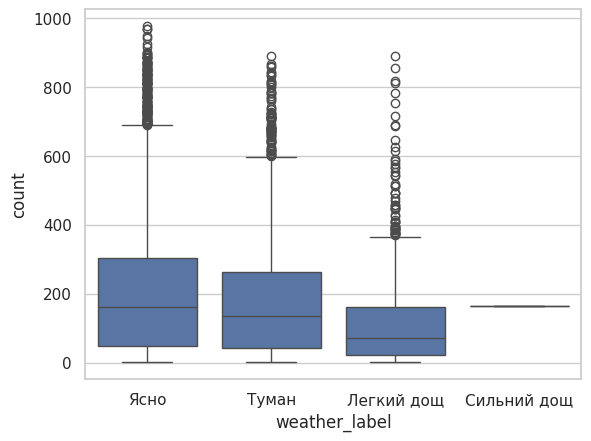

In [16]:
# Seaborn
sns.boxplot(data=df, x='weather_label', y='count');

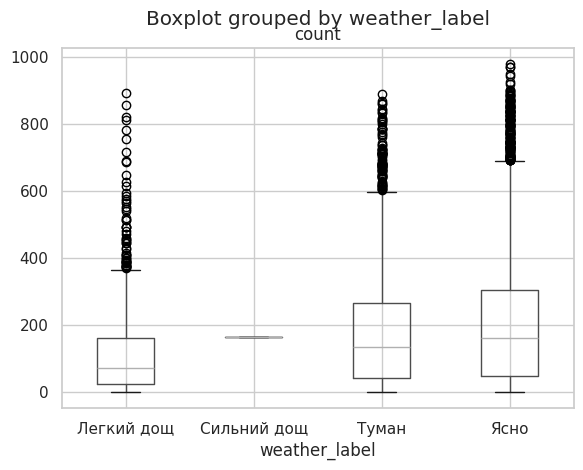

In [17]:
# Pandas
df.boxplot(column='count', by='weather_label');

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.



In [19]:
df.select_dtypes(include='number').columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'day', 'week',
       'weekday_num', 'year', 'month', 'hour'],
      dtype='object')

In [39]:
correlation = df[['count', 'casual', 'registered', 'temp', 'atemp', 'humidity', 'windspeed', 'season']].corr()

In [40]:
correlation

,count,casual,registered,temp,atemp,humidity,windspeed,season
count,1.000000,0.690414,0.970948,0.394454,0.389784,-0.317371,0.101369,0.163439
casual,0.690414,1.000000,0.497250,0.467097,0.462067,-0.348187,0.092276,0.096758
registered,0.970948,0.497250,1.000000,0.318571,0.314635,-0.265458,0.091052,0.164011
temp,0.394454,0.467097,0.318571,1.000000,0.984948,-0.064949,-0.017852,0.258689
atemp,0.389784,0.462067,0.314635,0.984948,1.000000,-0.043536,-0.057473,0.264744
humidity,-0.317371,-0.348187,-0.265458,-0.064949,-0.043536,1.000000,-0.318607,0.190610
windspeed,0.101369,0.092276,0.091052,-0.017852,-0.057473,-0.318607,1.000000,-0.147121
season,0.163439,0.096758,0.164011,0.258689,0.264744,0.190610,-0.147121,1.000000


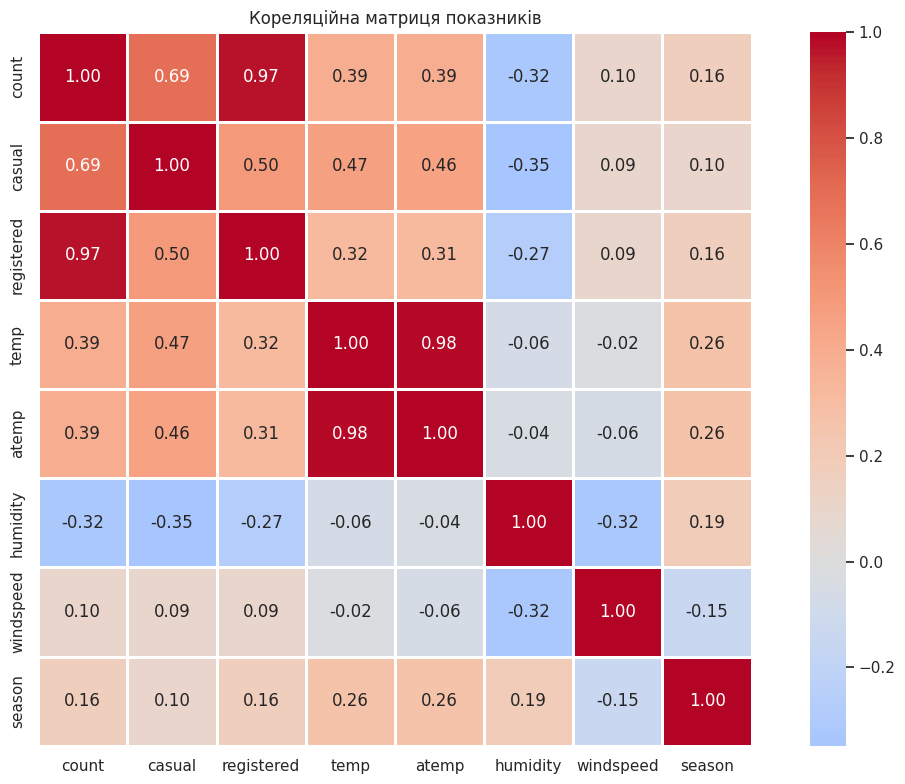

In [57]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f',center=0,
            square=True, linewidths=1)
plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

**Дайте відповіді на питання по графіку:**

**1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?**

Найсильніше з count корелюють registered (0.97) і casual (0.69) — але це наслідок формули count = casual + registered, а не природний зв'язок. З реальних факторів найсильніші — temp/atemp (0.39, помірна кореляція).

**2. Яка кореляція між temp та atemp? Чому?**

temp і atemp = 0.98 — майже ідеальна кореляція, бо atemp ("відчувається як") розраховується на основі temp з поправкою на вологість і вітер, тому відчуття температури дуже близьке до реальної.

**3. Які змінні мають негативну кореляцію?**

Негативна кореляція: humidity — з усіма змінними, крім season (найсильніше з count -0.32); windspeed — з humidity (-0.32) і season (-0.15). Логічно: вища вологість → менше оренд; сильніший вітер частіше у холодні сезони.



## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**

**1. Що показує "товщина" violin plot?**

Товщина в кожній точці по вертикальній осі — це щільність (частота) спостережень на цьому рівні count. Де скрипка ширша — там більше годин мали приблизно таку кількість оренд ("популярна" зона значень); де вузько/загострено — рідкісні значення.

**2. В якому кварталі найбільша варіабельність оренди?**

Q3 (літо) — найбільший розкид: std ≈ 197, IQR = 279, максимум 977, і водночас найвища медіана (195). Тобто в Q3 не лише орендують більше в середньому, а й самі значення сильніше "розкидані".

**3. Яка перевага violin plot над звичайним box plot?**

Box plot показує лише медіану, квартилі й вуса (5 чисел) — тому розподіли з різною формою можуть виглядати однаково. Violin plot додатково показує повну форму розподілу: чи є одне скупчення даних, чи має кілька окремих скупчень, симетричний чи скошений. Цю структуру box plot може приховати, а violin — показує явно.

In [58]:
df['season_q'] = df['season'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

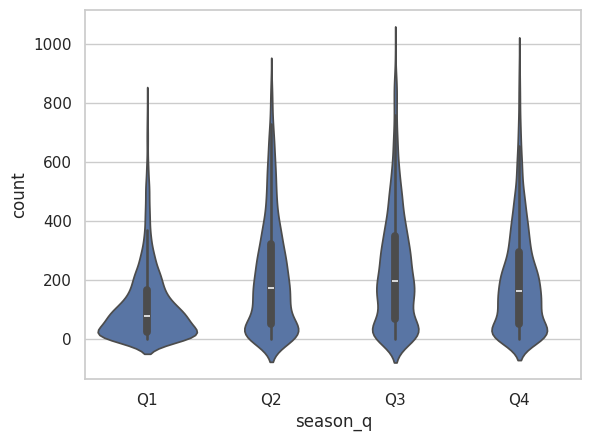

In [60]:
sns.violinplot(data=df, x='season_q', y='count');

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**

**1. Між якими змінними спостерігається найсильніший лінійний зв'язок?**

Найсильніший лінійний зв'язок серед розглянутих змінних — між temp і count (кореляція 0.39): чим тепліше, тим більше оренд. Це найчіткіший тренд серед скатерплотів temp/humidity/windspeed проти count.

**2. Яка характеристика найбільше відрізняється між кварталами?**

Найбільше між сезонами відрізняється temp (температура) — на діагональному графіку розподілу видно, що криві для різних сезонів практично не перекриваються (зима чітко зліва, літо чітко справа). Це логічно, оскільки сезон визначається саме температурним режимом. Для порівняння, humidity і windspeed мають розподіли, які значно сильніше накладаються один на одного між сезонами.

In [51]:
df['season_label'] = df['season'].map({1: 'Зима', 2: 'Весна', 3: 'Літо', 4: 'Осінь'})

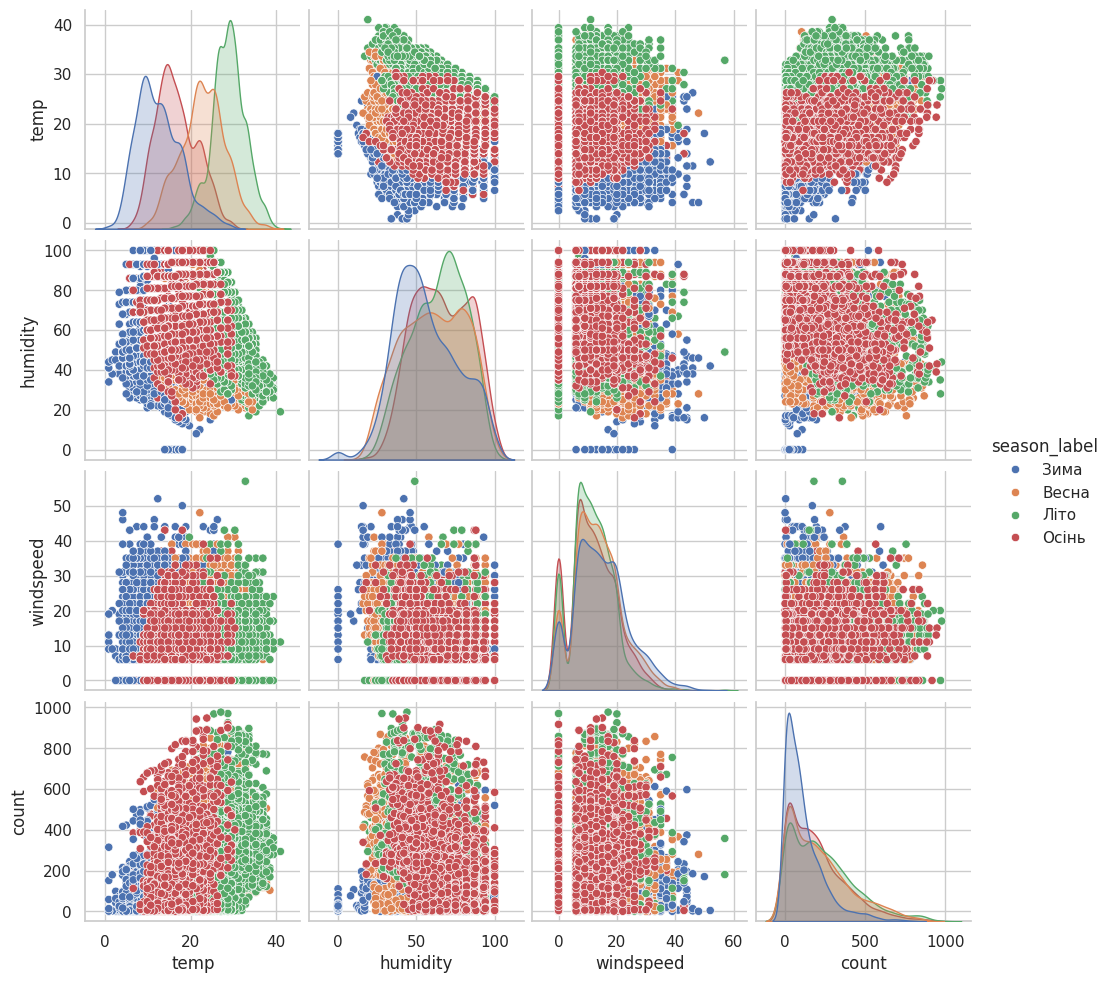

In [52]:
sns.pairplot(df[['temp', 'humidity', 'windspeed', 'count', 'season_label']], hue='season_label');

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**

**1. Що показують графіки по краях?**

Графіки по краях — це розподіли кожної окремої змінної.
Верхній графік показує розподіл temp (як часто зустрічаються різні температури), правий — розподіл count (як часто зустрічаються різні кількості оренд). Обидва розбиті по кольору на робочі/вихідні дні (hue).

**2. Чи є різниця у поведінці користувачів у робочий і неробочий день?**

Так, різниця є — але не в загальній кількості оренд (вона практично однакова: ~193 в робочі дні проти ~188.5 у вихідні), а в характері/патерні використання. У робочі дні розподіл має два виражені піки — це "commute"-патерн: люди орендують велосипед вранці (дорога на роботу) і ввечері (дорога додому). У вихідні дні такого чіткого двопікового патерну немає — попит розподілений рівномірніше протягом дня, оскільки люди катаються скоріше для дозвілля, без прив'язки до робочого графіка.

In [63]:
df['workingday_label'] = df['workingday'].map({1: 'Робочий', 0: 'Вихідний'})

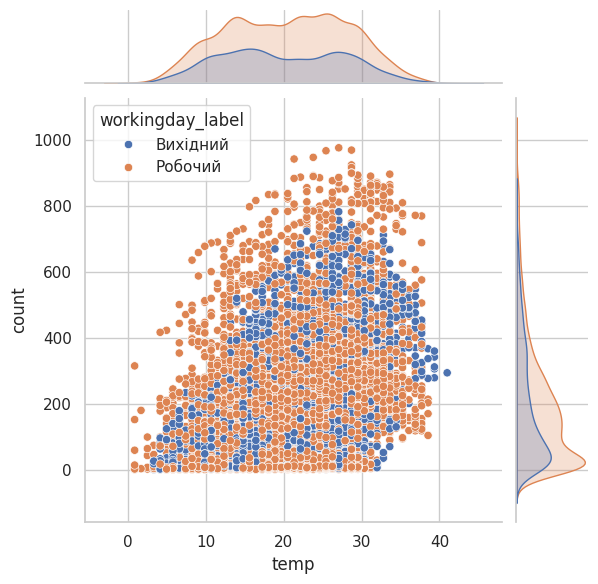

In [65]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday_label');